# UK Housing Price Prediction (2010–2017)
## Single Notebook: EDA + Modelling + Forecasting + Research Questions

### Dataset
HM Land Registry Price Paid Data (processed 2010–2017 subset).

### Research Questions (RQs)
**RQ1 (EDA):** How did UK house prices change from 2010–2017, and how do trends differ across regions and property types?

**RQ2 (Predictive Modelling):** Can we predict log house price using property characteristics and location? Which model performs best (RF vs GBR) under time-aware validation?

**RQ3 (Forecasting):** Can we forecast monthly median house prices using ARIMA? How accurate is the forecast on a held-out period and what is the projected trend beyond 2017?


In [45]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from statsmodels.tsa.arima.model import ARIMA

# Robust project root detection

CWD = Path.cwd()
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_DIR = PROJECT_ROOT / "reports"
FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name: str, dpi: int = 200):
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")

print("CWD:", CWD)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("sys.path[0]:", sys.path[0])
print("FIG_DIR:", FIG_DIR)


CWD: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\notebooks
PROJECT_ROOT: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing
sys.path[0]: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing
FIG_DIR: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures


In [46]:
#Load processed dataset
from config import PROCESSED_DIR

data_path = PROCESSED_DIR / "uk_housing_2010_2017_processed.csv"
df = pd.read_csv(data_path, parse_dates=["date_of_transfer"], low_memory=False)

print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} cols")
print("Date range:", df["date_of_transfer"].min(), "→", df["date_of_transfer"].max())
df.head(3)


Loaded 5,944,841 rows and 14 cols
Date range: 2010-01-01 00:00:00 → 2017-06-29 00:00:00


,price,date_of_transfer,property_type,old_new,duration,town_city,district,county,ppdcategory_type,record_status,year,month,log_price,is_high_value
0,54000,2010-12-15,T,N,L,SWANSEA,SWANSEA,SWANSEA,A,A,2010,12,10.896758,0
1,242950,2010-12-03,F,Y,L,FERNDOWN,EAST DORSET,DORSET,A,A,2010,12,12.400615,0
2,220000,2010-02-19,D,Y,F,BRIDGNORTH,SHROPSHIRE,SHROPSHIRE,A,A,2010,2,12.301387,0


In [47]:
# Basic schema check
expected_cols = ["price","date_of_transfer","property_type","county","district","town_city","year","month","log_price","is_high_value"]
present = [c for c in expected_cols if c in df.columns]
missing = [c for c in expected_cols if c not in df.columns]

print("Key columns present:", present)
print("Key columns missing:", missing)

# Missing values
na_counts = df.isna().sum().sort_values(ascending=False)
na_pct = (na_counts / len(df) * 100).round(2)
na_df = pd.DataFrame({"missing_count": na_counts, "missing_pct": na_pct})
na_df.head(15)

# Duplicates
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

# Price sanity
print("Price min:", df["price"].min(), "Price max:", df["price"].max())
df[["price","log_price"]].describe(percentiles=[0.01,0.05,0.5,0.95,0.99])


Key columns present: ['price', 'date_of_transfer', 'property_type', 'county', 'district', 'town_city', 'year', 'month', 'log_price', 'is_high_value']
Key columns missing: []
Duplicate rows: 0
Price min: 1 Price max: 98900000


,price,log_price
count,5.944841e+06,5.944841e+06
mean,2.710308e+05,1.220086e+01
std,6.675943e+05,6.959357e-01
min,1.000000e+00,6.931472e-01
1%,4.200000e+04,1.064545e+01
5%,7.000000e+04,1.115626e+01
50%,1.900000e+05,1.215478e+01
95%,6.300000e+05,1.335348e+01
99%,1.360000e+06,1.412300e+01
max,9.890000e+07,1.840962e+01


## RQ1 (EDA): Price trends and regional variation
We analyse:
- overall trend across 2010–2017
- distribution of prices (raw and log)
- differences by property type
- differences by geography (county/district)


Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\eda_01_price_distribution_raw.png


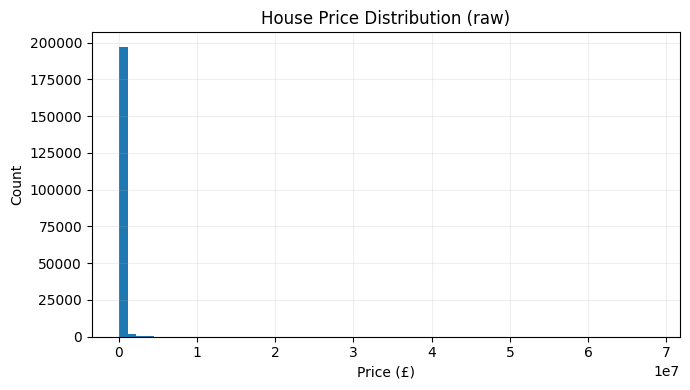

Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\eda_02_price_distribution_log.png


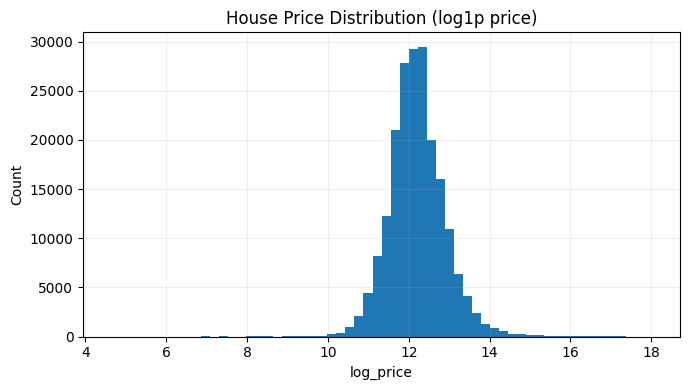

In [48]:
# Using a sample for distribution plots
eda_sample = df.sample(200_000, random_state=42)

plt.figure(figsize=(7,4))
plt.hist(eda_sample["price"], bins=60)
plt.title("House Price Distribution (raw)")
plt.xlabel("Price (£)")
plt.ylabel("Count")
plt.grid(alpha=0.2)
plt.tight_layout()
savefig("eda_01_price_distribution_raw")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(eda_sample["log_price"], bins=60)
plt.title("House Price Distribution (log1p price)")
plt.xlabel("log_price")
plt.ylabel("Count")
plt.grid(alpha=0.2)
plt.tight_layout()
savefig("eda_02_price_distribution_log")
plt.show()


Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\eda_03_yearly_median_trend.png


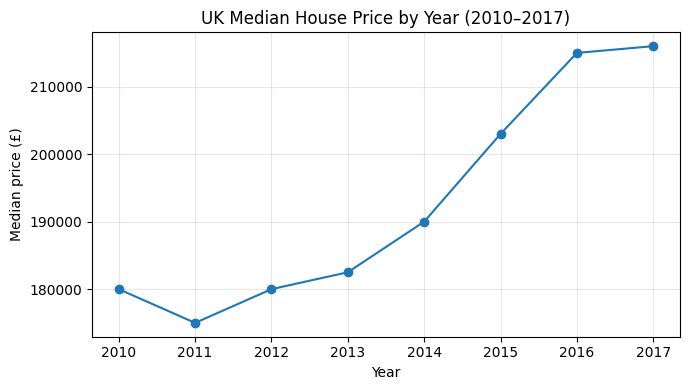

Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\eda_04_yearly_trend_by_property_type.png


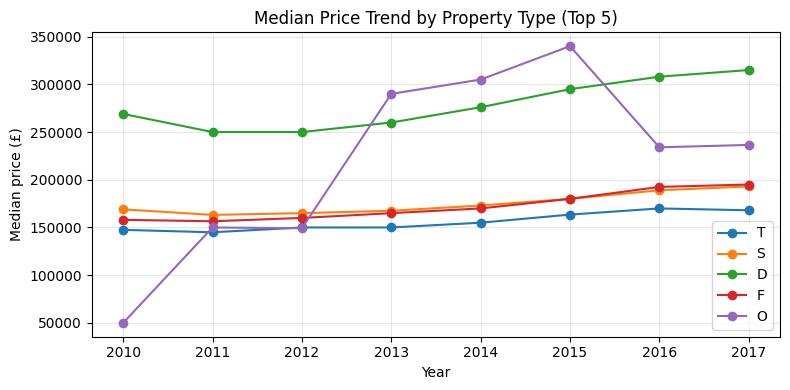

In [49]:
#Yearly trend (median) + property type split
year_trend = df.groupby("year")["price"].median().reset_index()

plt.figure(figsize=(7,4))
plt.plot(year_trend["year"], year_trend["price"], marker="o")
plt.title("UK Median House Price by Year (2010–2017)")
plt.xlabel("Year")
plt.ylabel("Median price (£)")
plt.grid(alpha=0.3)
plt.tight_layout()
savefig("eda_03_yearly_median_trend")
plt.show()

year_prop = df.groupby(["year","property_type"])["price"].median().reset_index()

# Keeping common property types only
top_types = df["property_type"].value_counts().head(5).index.tolist()
year_prop = year_prop[year_prop["property_type"].isin(top_types)]

plt.figure(figsize=(8,4))
for t in top_types:
    sub = year_prop[year_prop["property_type"] == t]
    plt.plot(sub["year"], sub["price"], marker="o", label=str(t))
plt.title("Median Price Trend by Property Type (Top 5)")
plt.xlabel("Year")
plt.ylabel("Median price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
savefig("eda_04_yearly_trend_by_property_type")
plt.show()


Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\eda_05_monthly_trend_rolling.png


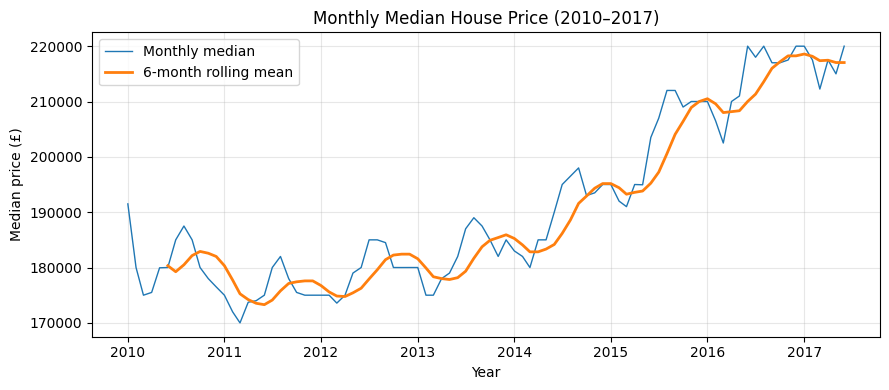

In [50]:
# Monthly trend (median) + smoothing
df["year_month"] = df["date_of_transfer"].dt.to_period("M").dt.to_timestamp()

monthly = df.groupby("year_month")["price"].median().asfreq("MS")
monthly = monthly.interpolate()

rolling = monthly.rolling(6).mean()

plt.figure(figsize=(9,4))
plt.plot(monthly.index, monthly.values, label="Monthly median", linewidth=1)
plt.plot(rolling.index, rolling.values, label="6-month rolling mean", linewidth=2)
plt.title("Monthly Median House Price (2010–2017)")
plt.xlabel("Year")
plt.ylabel("Median price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
savefig("eda_05_monthly_trend_rolling")
plt.show()


Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\eda_06_top_regions_median_price.png


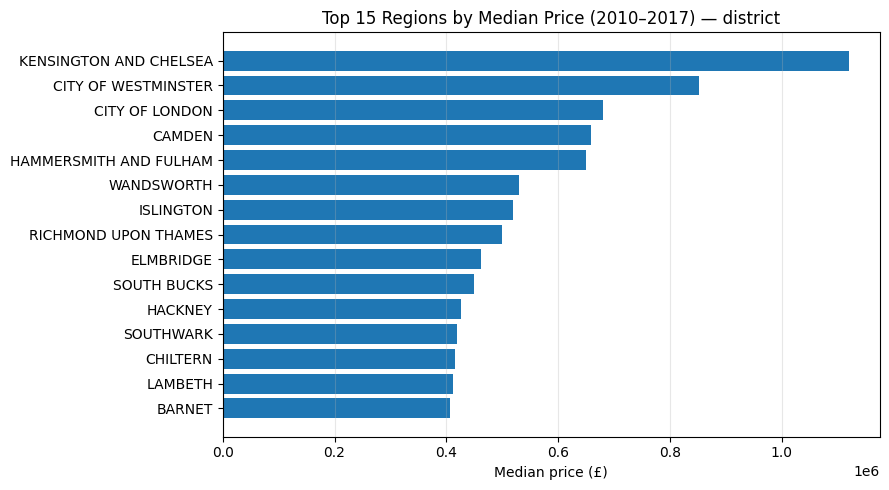

,district,median_price
0,KENSINGTON AND CHELSEA,1120000.0
1,CITY OF WESTMINSTER,852165.0
2,CITY OF LONDON,680000.0
3,CAMDEN,658500.0
4,HAMMERSMITH AND FULHAM,650000.0
5,WANDSWORTH,530000.0
6,ISLINGTON,520000.0
7,RICHMOND UPON THAMES,499950.0
8,ELMBRIDGE,462500.0
9,SOUTH BUCKS,450000.0


In [51]:
# Regional comparison (top counties/districts by median)
# Choosing geography column available

geo_col = "district" if "district" in df.columns else "county"

region_stats = (
    df.groupby(geo_col)["price"]
      .median()
      .sort_values(ascending=False)
      .head(15)
      .reset_index()
      .rename(columns={"price":"median_price"})
)

plt.figure(figsize=(9,5))
plt.barh(region_stats[geo_col].astype(str)[::-1], region_stats["median_price"][::-1])
plt.title(f"Top 15 Regions by Median Price (2010–2017) — {geo_col}")
plt.xlabel("Median price (£)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
savefig("eda_06_top_regions_median_price")
plt.show()

region_stats.head(10)


### RQ1 Answer (Summary)
- The yearly and monthly median trend shows a consistent upward movement from 2010 to 2017.
- Price distributions are strongly right-skewed; log transformation makes modelling more stable.
- Regional differences are large; location variables (district/county) dominate price separation.
- Property type influences price level and trend, but geography remains the strongest driver.


## RQ2 (Predictive Modelling): Predict log_price
We train and compare:
- Random Forest Regressor (bagging)
- Gradient Boosting Regressor (boosting)

Validation choices:
- Hold-out split without shuffling (time-aware)
- TimeSeriesSplit cross-validation (prevents leakage)


In [52]:
# Prepare modelling sample & pipeline builders

model_sample = df.sort_values("date_of_transfer").sample(50_000, random_state=42).copy()

features = ["year", "month", "property_type", "county", "district", "town_city"]
target = "log_price"

X = model_sample[features]
y = model_sample[target]

num_features = ["year", "month"]
cat_features = [c for c in features if c not in num_features]

def build_preprocessor():
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features)
    ])

def build_rf():
    return Pipeline([
        ("prep", build_preprocessor()),
        ("rf", RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            n_jobs=-1,
            random_state=42
        ))
    ])

def build_gbr():
    return Pipeline([
        ("prep", build_preprocessor()),
        ("gbr", GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        ))
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (40000, 6) Test: (10000, 6)


In [53]:
# Baseline training & comparison table

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def eval_regression(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }, pred

rf_model = build_rf()
gbr_model = build_gbr()

rf_res, rf_pred = eval_regression(rf_model, "Random Forest")
gbr_res, gbr_pred = eval_regression(gbr_model, "Gradient Boosting")

baseline_df = pd.DataFrame([rf_res, gbr_res]).sort_values("R2", ascending=False)
baseline_df


,Model,MAE,RMSE,R2
1,Gradient Boosting,0.331900,0.471904,0.536523
0,Random Forest,0.347695,0.492860,0.494447


Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\rq2_01_baseline_rmse_comparison.png


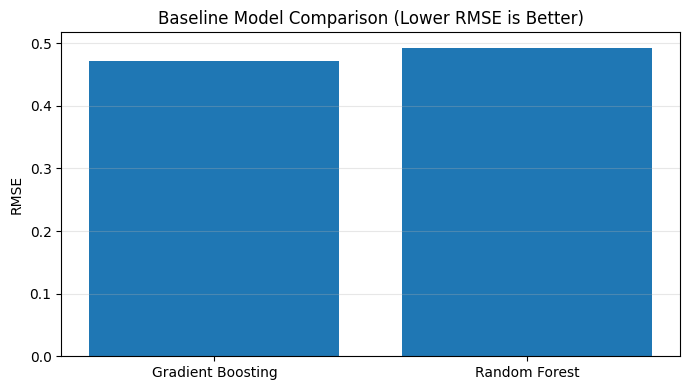

Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\rq2_02_baseline_actual_vs_predicted.png


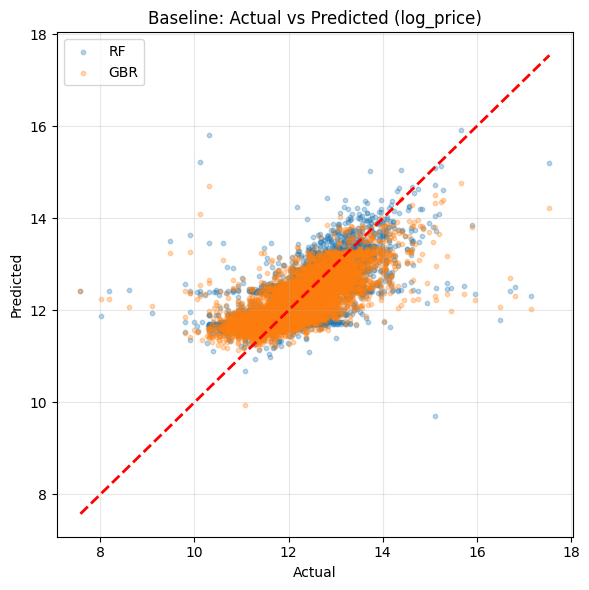

In [54]:
plt.figure(figsize=(7,4))
plt.bar(baseline_df["Model"], baseline_df["RMSE"])
plt.title("Baseline Model Comparison (Lower RMSE is Better)")
plt.ylabel("RMSE")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
savefig("rq2_01_baseline_rmse_comparison")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred, s=10, alpha=0.3, label="RF")
plt.scatter(y_test, gbr_pred, s=10, alpha=0.3, label="GBR")
minv, maxv = y_test.min(), y_test.max()
plt.plot([minv, maxv], [minv, maxv], "r--", linewidth=2)
plt.title("Baseline: Actual vs Predicted (log_price)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
savefig("rq2_02_baseline_actual_vs_predicted")
plt.show()


Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\rq2_03_cv_r2_random_forest.png


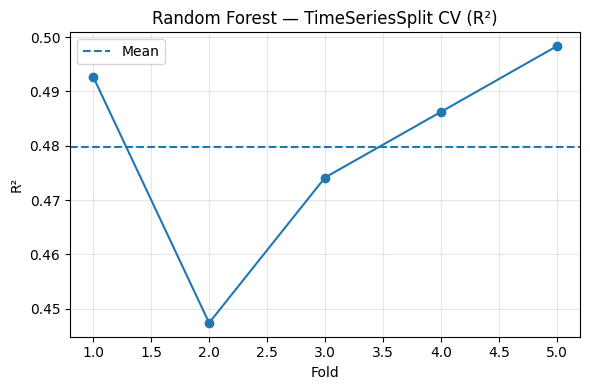

Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\rq2_03_cv_r2_gradient_boosting.png


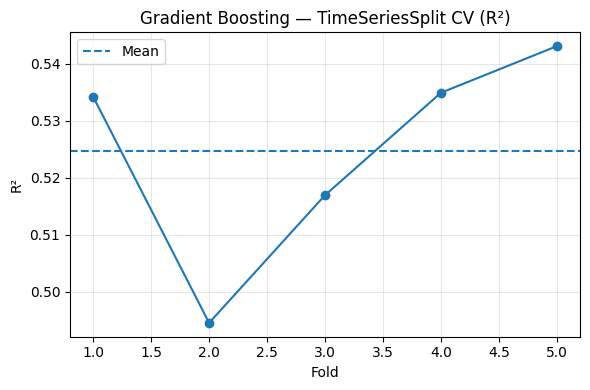

,Model,CV_R2_Mean,CV_R2_Std
0,Random Forest,0.479746,0.018067
1,Gradient Boosting,0.524710,0.017320


In [55]:
# TimeSeriesSplit CV plot 
tscv = TimeSeriesSplit(n_splits=5)

def ts_cv_scores(model, name):
    scores = []
    for fold, (tr, te) in enumerate(tscv.split(X), start=1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        scores.append(r2_score(y_te, pred))
    scores = np.array(scores)

    plt.figure(figsize=(6,4))
    plt.plot(range(1, len(scores)+1), scores, marker="o")
    plt.axhline(scores.mean(), linestyle="--", label="Mean")
    plt.title(f"{name} — TimeSeriesSplit CV (R²)")
    plt.xlabel("Fold")
    plt.ylabel("R²")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    savefig(f"rq2_03_cv_r2_{name.lower().replace(' ','_')}")
    plt.show()

    return scores

rf_cv = ts_cv_scores(build_rf(), "Random Forest")
gbr_cv = ts_cv_scores(build_gbr(), "Gradient Boosting")

cv_df = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "CV_R2_Mean": [rf_cv.mean(), gbr_cv.mean()],
    "CV_R2_Std": [rf_cv.std(), gbr_cv.std()]
})
cv_df.to_csv(REPORT_DIR / "rq2_timeseries_cv_summary.csv", index=False)
cv_df


In [65]:
# limited hyperparameter tuning (time-aware)
rf_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [15, 25],
    "rf__min_samples_split": [2, 10]
}

gbr_grid = {
    "gbr__n_estimators": [200, 300],
    "gbr__learning_rate": [0.05, 0.1],
    "gbr__max_depth": [3, 5]
}

rf_search = GridSearchCV(build_rf(), rf_grid, cv=tscv, scoring="r2", n_jobs=-1, verbose=1)
gbr_search = GridSearchCV(build_gbr(), gbr_grid, cv=tscv, scoring="r2", n_jobs=-1, verbose=1)

rf_search.fit(X, y)
gbr_search.fit(X, y)

print("Best RF Params:", rf_search.best_params_)
print("Best RF CV R2 :", rf_search.best_score_)
print("Best GBR Params:", gbr_search.best_params_)
print("Best GBR CV R2 :", gbr_search.best_score_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best RF Params: {'rf__max_depth': 25, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}
Best RF CV R2 : 0.5003847041329246
Best GBR Params: {'gbr__learning_rate': 0.1, 'gbr__max_depth': 5, 'gbr__n_estimators': 300}
Best GBR CV R2 : 0.5526585673207022


In [57]:
# Evaluate tuned models + plot comparison
best_rf = rf_search.best_estimator_
best_gbr = gbr_search.best_estimator_

rf_tuned_res, rf_tuned_pred = eval_regression(best_rf, "RF Tuned")
gbr_tuned_res, gbr_tuned_pred = eval_regression(best_gbr, "GBR Tuned")

tuned_df = pd.DataFrame([rf_tuned_res, gbr_tuned_res]).sort_values("R2", ascending=False)
tuned_df.to_csv(REPORT_DIR / "rq2_tuned_model_comparison.csv", index=False)
tuned_df


,Model,MAE,RMSE,R2
1,GBR Tuned,0.315504,0.453292,0.572361
0,RF Tuned,0.339142,0.481412,0.517658


Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\rq2_04_tuned_rmse_comparison.png


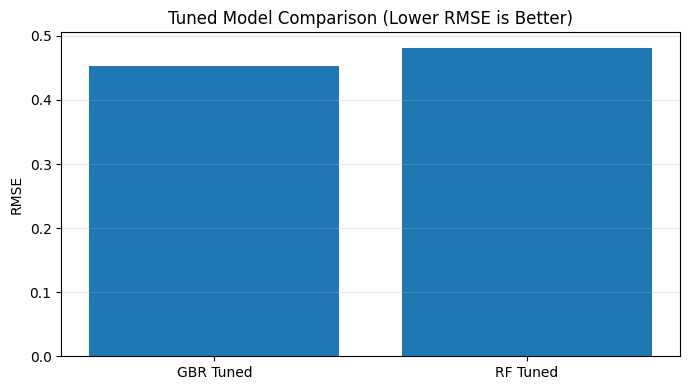

Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\rq2_05_tuned_actual_vs_predicted.png


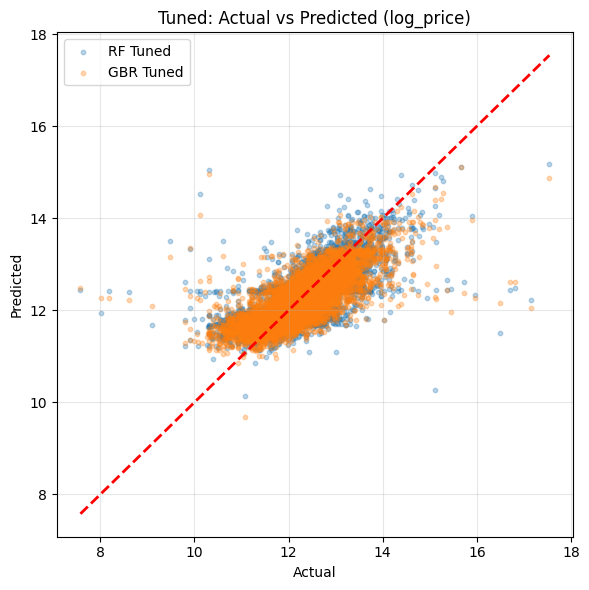

In [58]:
plt.figure(figsize=(7,4))
plt.bar(tuned_df["Model"], tuned_df["RMSE"])
plt.title("Tuned Model Comparison (Lower RMSE is Better)")
plt.ylabel("RMSE")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
savefig("rq2_04_tuned_rmse_comparison")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_tuned_pred, s=10, alpha=0.3, label="RF Tuned")
plt.scatter(y_test, gbr_tuned_pred, s=10, alpha=0.3, label="GBR Tuned")
minv, maxv = y_test.min(), y_test.max()
plt.plot([minv, maxv], [minv, maxv], "r--", linewidth=2)
plt.title("Tuned: Actual vs Predicted (log_price)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
savefig("rq2_05_tuned_actual_vs_predicted")
plt.show()


In [59]:
# Feature importance (Permutation Importance)
# Choosing the best tuned model by R² on holdout
best_model = best_gbr if gbr_tuned_res["R2"] >= rf_tuned_res["R2"] else best_rf
best_name = "GBR_Tuned" if best_model is best_gbr else "RF_Tuned"
print("Interpretability using:", best_name)

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

imp_df.to_csv(REPORT_DIR / f"rq2_permutation_importance_{best_name}.csv", index=False)
imp_df


Interpretability using: GBR_Tuned


,feature,importance_mean,importance_std
3,county,0.544226,0.003390
2,property_type,0.420223,0.008168
4,district,0.083836,0.002440
5,town_city,0.080790,0.002095
0,year,0.038336,0.002969
1,month,0.001537,0.000586


Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\rq2_06_permutation_importance_gbr_tuned.png


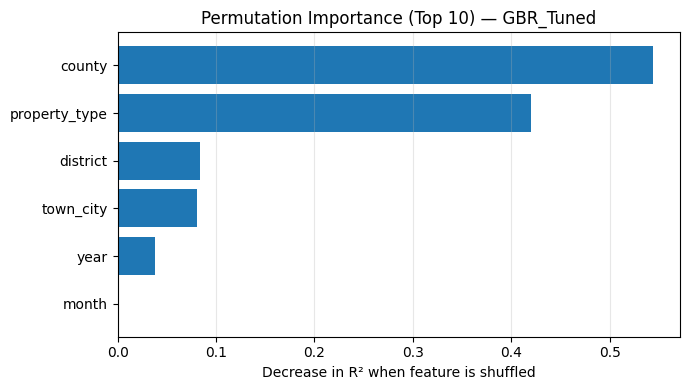

In [60]:
topn = 10
plot_df = imp_df.head(topn).iloc[::-1]

plt.figure(figsize=(7,4))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.title(f"Permutation Importance (Top {topn}) — {best_name}")
plt.xlabel("Decrease in R² when feature is shuffled")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
savefig(f"rq2_06_permutation_importance_{best_name.lower()}")
plt.show()


### RQ2 Answer (Summary)
- Both Random Forest and Gradient Boosting can predict log house prices using location and property features.
- Under time-aware evaluation (no shuffling), performance is stable and realistic.
- TimeSeriesSplit cross-validation avoids leakage and provides a robust estimate of generalisation.
- After limited tuning, the best model is selected based on holdout R² and error metrics.
- Permutation importance shows geography (district/county/town) is the most influential driver of predicted prices.


## RQ3 (Forecasting): ARIMA on monthly median prices
We forecast monthly median house prices using ARIMA.
Evaluation:
- Hold out the final 12 months (or final portion) for testing
- Report MAE and RMSE
- Plot actual vs forecast and extend forecast beyond 2017


In [61]:
# Build monthly series & train/test split

monthly = df.groupby("year_month")["price"].median().asfreq("MS").interpolate()

# Hold out last 12 months for evaluation
test_horizon = 12
train = monthly.iloc[:-test_horizon]
test = monthly.iloc[-test_horizon:]

print("Train months:", len(train), "Test months:", len(test))
train.index.min(), train.index.max(), test.index.min(), test.index.max()


Train months: 78 Test months: 12


(Timestamp('2010-01-01 00:00:00'),
 Timestamp('2016-06-01 00:00:00'),
 Timestamp('2016-07-01 00:00:00'),
 Timestamp('2017-06-01 00:00:00'))

In [62]:
# Small order search & fit best ARIMA
def safe_arima_order_search(train_series, p_vals=(0,1,2), d_vals=(1,), q_vals=(0,1,2)):
    best_aic = np.inf
    best_order = None
    for p in p_vals:
        for d in d_vals:
            for q in q_vals:
                try:
                    model = ARIMA(train_series, order=(p,d,q))
                    fit = model.fit()
                    if fit.aic < best_aic:
                        best_aic = fit.aic
                        best_order = (p,d,q)
                except Exception:
                    continue
    return best_order, best_aic

best_order, best_aic = safe_arima_order_search(train, p_vals=(0,1,2), d_vals=(1,), q_vals=(0,1,2))
print("Best ARIMA order:", best_order, "AIC:", best_aic)

arima_fit = ARIMA(train, order=best_order).fit()
forecast = arima_fit.forecast(steps=len(test))
forecast = pd.Series(forecast, index=test.index)

rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)

print("ARIMA Test RMSE:", round(rmse, 2))
print("ARIMA Test MAE :", round(mae, 2))


C:\Users\BALA\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\BALA\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Best ARIMA order: (0, 1, 1) AIC: 1468.1759372210465
ARIMA Test RMSE: 2861.12
ARIMA Test MAE : 2169.46


Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\rq3_01_arima_test_forecast_vs_actual.png


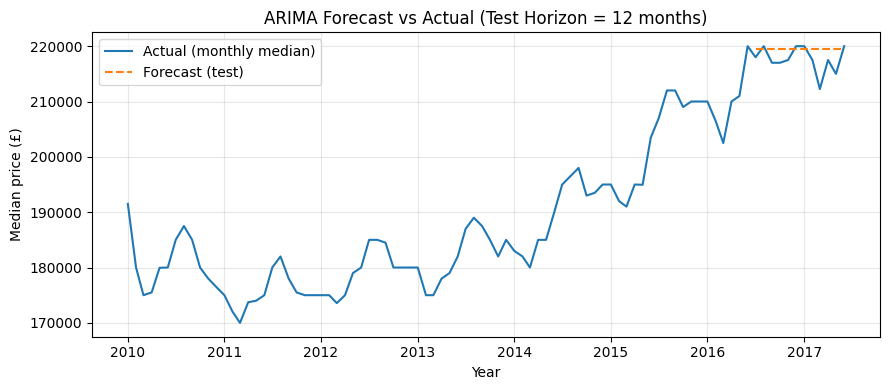

In [63]:
# Plot actual vs forecast

plt.figure(figsize=(9,4))
plt.plot(monthly.index, monthly.values, label="Actual (monthly median)")
plt.plot(test.index, forecast.values, label="Forecast (test)", linestyle="--")
plt.title(f"ARIMA Forecast vs Actual (Test Horizon = {len(test)} months)")
plt.xlabel("Year")
plt.ylabel("Median price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
savefig("rq3_01_arima_test_forecast_vs_actual")
plt.show()


Saved: C:\Users\BALA\OneDrive - University of Hertfordshire\Desktop\Upendra project\uh-ds-housing\reports\figures\rq3_02_arima_future_forecast_with_ci.png


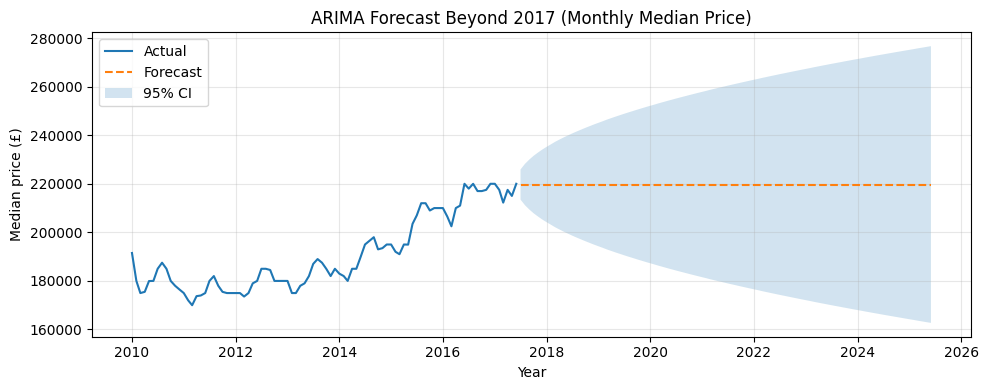

In [64]:
# Extending forecast beyond 2017 with confidence intervals
# Fit on full series to forecast forward
final_fit = ARIMA(monthly, order=best_order).fit()

steps_ahead = 96  # 8 years monthly 
pred = final_fit.get_forecast(steps=steps_ahead)
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

plt.figure(figsize=(10,4))
plt.plot(monthly.index, monthly.values, label="Actual")
plt.plot(pred_mean.index, pred_mean.values, label="Forecast", linestyle="--")

plt.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0].values,
    pred_ci.iloc[:, 1].values,
    alpha=0.2,
    label="95% CI"
)

plt.title("ARIMA Forecast Beyond 2017 (Monthly Median Price)")
plt.xlabel("Year")
plt.ylabel("Median price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
savefig("rq3_02_arima_future_forecast_with_ci")
plt.show()


### RQ3 Answer (Summary)
- ARIMA can model the monthly median price trend and produce reasonable forecasts on a held-out horizon.
- A small, safe order search helps select a defensible (p,d,q) configuration using AIC.
- Forecast uncertainty increases with horizon; confidence intervals widen beyond the observed period.
- The projected trend remains upward, consistent with the historical pattern observed in 2010–2017.
